# Graph classification sweep performance 

Plots showing the performance for the graph classification on the CosMx Pancrease data with no diabetes and Type 1 Diabetes conditions.

- InterScale (GCN + Transformer)
- GCN
- PCATransformer

In [17]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'
DATA = "damond19"

LRZ cluster


In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{BASE_DIR_REPO}/InterScale_reproducibility')
sys.path.insert(0, str(project_root))

In [7]:
import wandb
import pandas as pd
wandb.login()

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

# ste sys path correctly
#from src.wandb import load_result_as_df, compute_mean_and_std, summary_df, plot_robustness
from src.wandb import Wandb_evaluation, plot_f1_across_seeds

In [8]:
import yaml
import matplotlib.pyplot as plt

with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

## Load WandB IDs

In [9]:
GNN_sweep = "pzz25qfw"
InterScale_sweep = "463vbe99"
PCATrans_sweep = "8jvwjnba"

## Graph Classification performance

In [10]:
SWEEP_GOAL = 'robustness'
CLASSES = ['Long-duration', 'Non-diabetic', 'Onset']

Q: Why does PCATrans not have test_f1 scores?

In [11]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, True, False, SWEEP_GOAL, CLASSES)
PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, False, True, SWEEP_GOAL, CLASSES)
InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, True, True, SWEEP_GOAL, CLASSES)

In [12]:
PCATrans_wandb.get_dataframe()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro,test_f1_macro,test_f1_class_Long-duration,test_f1_class_Non-diabetic,test_f1_class_Onset
0,abaffng9,damond19_clas_graph_44_self-attn-transformer_,44,finished,0,0,None,11762.440919,19363,0.621962,0.621962,0.437583,0.195164,0.467114,0.650472
1,jgvxzgrm,damond19_clas_graph_44_self-attn-transformer_,43,finished,0,0,None,34678.653470,19363,0.686777,0.686777,0.481403,0.338680,0.794020,0.311508
2,ans8tosx,damond19_clas_graph_44_self-attn-transformer_,42,finished,0,0,None,12542.722193,19363,0.417101,0.417101,0.340932,0.242777,0.368731,0.411289
3,zz94dnr0,damond19_clas_graph_44_self-attn-transformer_,41,finished,0,0,None,12629.095086,19363,0.366464,0.366464,0.226000,0.065584,0.055070,0.557344
4,avjlrawq,damond19_clas_graph_44_self-attn-transformer_,40,finished,0,0,None,9207.426502,19363,0.442564,0.442564,0.342864,0.000000,0.323093,0.705500


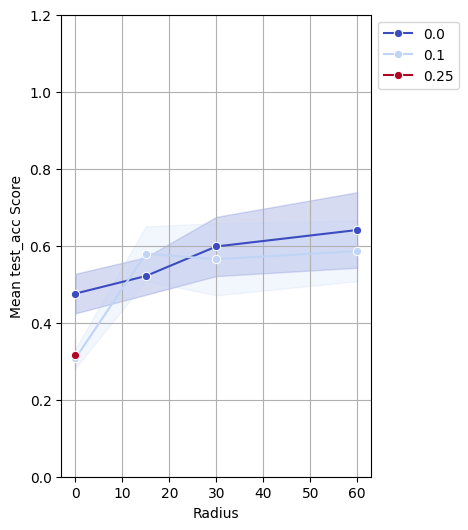

In [13]:
GNN_wandb.plot_robustness(metric="test_acc", save_path = f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/graph_class")

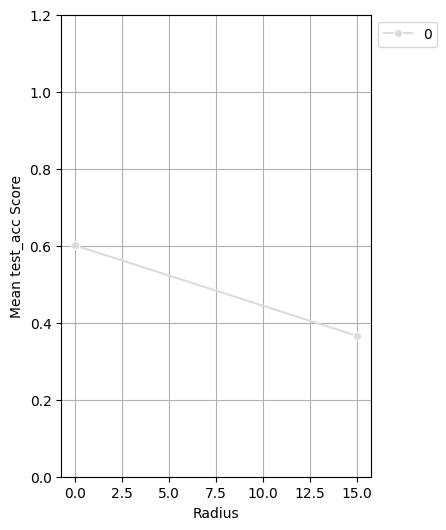

In [14]:
InterScale_wandb.plot_robustness(metric="test_acc", save_path = f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/graph_class")

FileNotFoundError: [Errno 2] No such file or directory: '/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/InterScale_reproducibility/figures/damond19/graph_class/self-attn-transformer__graph_classification_radius_vs_test_acc.jpg'

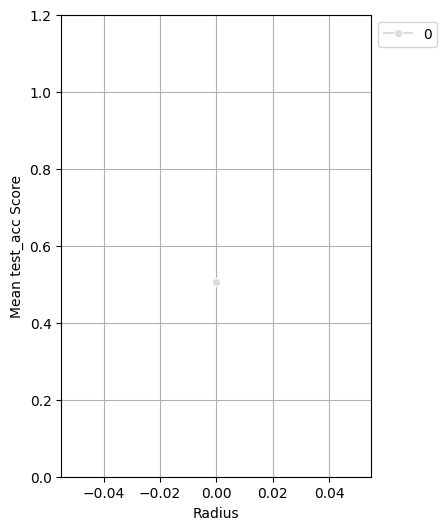

In [18]:
PCATrans_wandb.plot_robustness(metric="test_acc", save_path = f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/graph_class")

            model                        class      mean       std  n_seeds
0             GCN  test_f1_class_Long-duration  0.221928  0.093541        5
1             GCN   test_f1_class_Non-diabetic  0.473784  0.092350        5
2             GCN          test_f1_class_Onset  0.373059  0.055197        5
3      InterScale  test_f1_class_Long-duration  0.307101  0.115691        5
4      InterScale   test_f1_class_Non-diabetic  0.656176  0.327321        5
5      InterScale          test_f1_class_Onset  0.365837  0.170405        5
6  PCATransformer  test_f1_class_Long-duration  0.168441  0.136174        5
7  PCATransformer   test_f1_class_Non-diabetic  0.401606  0.267213        5
8  PCATransformer          test_f1_class_Onset  0.527223  0.164206        5


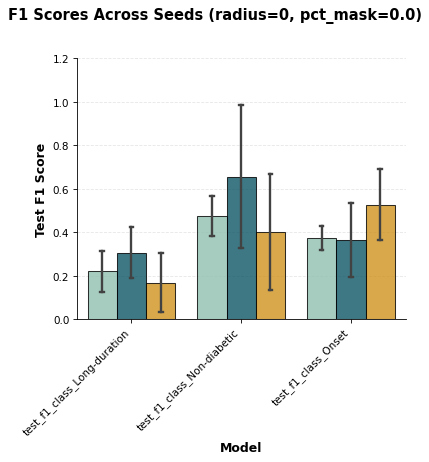

In [19]:
wandb_evals = [GNN_wandb, InterScale_wandb, PCATrans_wandb]  # Your list of dataframes

g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius=0,
    pct_mask_nodes=0.0,
    BASE_DIR_REPO=BASE_DIR_REPO,
    height=6,
    aspect=0.9,
    save_path=f'{DATA}/graph_class/f1_across_seeds'
)
plt.show()
#
# Save with high DPI from config
# g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)

# Interpretation of CLS token

Given the sweep, we obtain the best model and check the CLS token.

In [13]:
from InterScale.evaluation.graph_classification import scale_cls_by_sample, calculate_pr_auc, plot_adata_grouped_heatmaps#, plot_adata_grouped_heatmaps
import squidpy as sq
import scanpy as sc
import numpy as np

In [17]:
best_run_id = InterScale_wandb.get_best_run_id(metric="test_acc")

Best run for test_acc: 9kwjrcx0 (value: 0.8197)


In [18]:
df = InterScale_wandb.get_dataframe()
df[df['id'] == best_run_id]

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1_class_Long-duration,test_f1_class_Non-diabetic,test_f1_class_Onset
3,9kwjrcx0,damond19_clas_graph_44_GCN_self-attn-transformer_,42,finished,0,0,None,20277.609455,34627,0.819734,None,0.416667,0.950556,0.42682


In [19]:
adata = sc.read_h5ad(os.path.join(BASE_DIR_PROJECT, "data/damond19_pp.h5ad"))

In [22]:
import InterScale as interscale

combined_model, model_config, adata = InterScale_wandb.load_model(best_run_id, adata)

wandb:   1 of 1 files downloaded.  
/usr/local/lib/python3.10/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[pct-norm-99] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Model artifact downloaded to: /workspace/artifacts/model-9kwjrcx0:v0
WeightedCE with class weights:  tensor([1.1033, 0.9875, 0.9251], dtype=torch.float64)
Loading model from /workspace/artifacts/model-9kwjrcx0:v0/modelmodel.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown
Model loaded successfully from run: 9kwjrcx0


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/model/base/_base_model.py:598: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you 

In [ ]:
result_ld = combined_model.get_model_output(adata[adata.obs['stage'] == 'Long-duration'], prefix = 'combined')
result_nd = combined_model.get_model_output(adata[adata.obs['stage'] == 'Non-diabetic'], prefix = 'combined')
result_onset = combined_model.get_model_output(adata[adata.obs['stage'] == 'Onset'], prefix = 'combined')

INFO     Received view of anndata, making copy.                                                                    


/usr/local/lib/python3.10/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[pct-norm-99] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Load GEX from .layers/pct-norm-99
call new
{'stage': ['Long-duration']}


In [ ]:
scale_cls_by_sample(result_ld, 'sliding_window_square')
scale_cls_by_sample(result_nd, "sliding_window_square")
scale_cls_by_sample(result_onset, "sliding_window_square")

In [ ]:
GROUP = 'cell_type_coarse'
fig = plot_adata_grouped_heatmaps(
        adata_dict={'ND': result_nd, 'T1D': result_t1d},
        group_by=GROUP,
        value_cols=['combined_cls_horizontal_scaled', 'combined_cls_vertical_scaled'],
    agg_func='mean',
        figsize=(10, 8),
        save_path=f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/graph_class/cls_{GROUP}.png"
    )

In [ ]:
val_min = result_t1d.obs['combined_cls_horizontal'].min()
val_max = result_t1d.obs['combined_cls_horizontal'].max()
print(val_min, val_max)

In [ ]:
data_t1d = result_t1d.obs.groupby('cell_type_coarse').agg(
    mean_cls_horizontal=('combined_cls_horizontal_scaled', 'mean'),
    mean_cls_vertical=('combined_cls_vertical_scaled', 'mean')
)

data_nd = result_nd.obs.groupby('cell_type_coarse').agg(
    mean_cls_horizontal=('combined_cls_horizontal_scaled', 'mean'),
    mean_cls_vertical=('combined_cls_vertical_scaled', 'mean')
)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(5, 6))

# Get min/max for shared color scale
vmin = min(data_t1d.values.min(), data_nd.values.min())
vmax = max(data_t1d.values.max(), data_nd.values.max())

# Plot with shared color scale
sns.heatmap(data_t1d, annot=True, linewidth=.5, fmt='.2f', 
            ax=axes[0], vmin=vmin, vmax=vmax, cbar=False, cmap = PALETTE)
axes[0].set_title('T1D')

sns.heatmap(data_nd, annot=True, linewidth=.5, fmt='.2f', 
            ax=axes[1], vmin=vmin, vmax=vmax, cmap = PALETTE)
axes[1].set_title('ND')

plt.tight_layout()
plt.show()

In [ ]:
# assign cell type colors
color_list = [CELL_TYPE_COLORS[ct] for ct in adata.obs[GROUP].cat.categories]
result_t1d.uns[f'{GROUP}_colors'] = color_list
result_nd.uns[f'{GROUP}_colors'] = color_list

In [ ]:
result_t1d

In [ ]:
image_nr_long = np.unique(result_t1d.obs['slide_fov'][result_t1d.obs['split'] == 'test'])
image_subset = list(np.random.choice(image_nr_long, 2))
sq.pl.spatial_scatter(result_t1d[result_t1d.obs['split'] == 'test'], 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled', GROUP],
                      library_key = 'slide_fov',
                      library_id = image_subset,
                    cmap = PALETTE,
                    shape= None,
                      ncols = 4,
                      size = 50,
                      save = f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/graph_class/"
)

In [ ]:
image_nr_long = np.unique(result_nd.obs['slide_fov'][result_t1d.obs['split'] == 'test'])
image_subset = list(np.random.choice(image_nr_long, 2))
sq.pl.spatial_scatter(result_nd[result_nd.obs['split'] == 'test'], 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled', GROUP, ],
                      library_key = 'slide_fov',
                      library_id = image_subset,
                    cmap = PALETTE,
                    shape= None,
                      ncols = 4,
                      size = 50,
                      save = f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/graph_class/"
)